In [8]:
# ✅ STEP 1: Import Required Libraries
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#%matplotlib inline  # Ensures plots display in notebook


In [16]:

def load_dataset(folder_path, image_size=(100, 100)):
    X = []
    y = []
    labels = []

    for idx, person in enumerate(sorted(os.listdir(folder_path))):
        person_path = os.path.join(folder_path, person)
        if not os.path.isdir(person_path):
            continue
        labels.append(person)
        for file in os.listdir(person_path):
            file_path = os.path.join(person_path, file)
            try:
                img = Image.open(file_path).convert('RGB')
                img = img.resize(image_size)
                img_array = np.array(img).flatten()
                X.append(img_array)
                y.append(idx)
            except Exception as e:
                print(f"Skipping {file_path}: {e}")

    return np.array(X), np.array(y), labels


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
dataset_path = "/content/drive/MyDrive/cse445_project/Face_Data_cropped"

# Load images
X, y, label_names = load_dataset(dataset_path, image_size=(100, 100))

# Show label index mapping
print("Label Index Mapping:")
for i, name in enumerate(label_names):
    print(f"{i} → {name}")


Label Index Mapping:
0 → Alian_1
1 → Elon_musk_5
2 → Fida_2
3 → Mashrafi_8
4 → Messi_3
5 → Mofidul_0
6 → Sakib_9
7 → Shundar_pichai_4
8 → Zayan_7
9 → Zuhayr_6


In [23]:
# First split: Train (64%) + Temp (36%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.36, random_state=42, stratify=y
)

# Second split: Validation (16%) + Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=20/36, random_state=42, stratify=y_temp
)


In [24]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_val_pred = knn.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))


Validation Accuracy: 0.7857142857142857
Confusion Matrix:
 [[3 0 0 0 0 0 0 0 0 0]
 [0 2 0 1 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 0 0 0]
 [0 0 0 3 0 0 0 0 0 0]
 [0 2 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 0 2 0 0 0]
 [0 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 3 0]
 [0 0 0 0 0 0 0 0 1 2]]


In [25]:
from sklearn.metrics import classification_report

# y_true = actual labels, y_pred = model predictions
print(classification_report(y_val, y_val_pred, target_names=label_names))


                  precision    recall  f1-score   support

         Alian_1       1.00      1.00      1.00         3
     Elon_musk_5       0.50      0.67      0.57         3
          Fida_2       1.00      1.00      1.00         3
      Mashrafi_8       0.75      1.00      0.86         3
         Messi_3       0.50      0.33      0.40         3
       Mofidul_0       1.00      1.00      1.00         3
         Sakib_9       0.67      1.00      0.80         2
Shundar_pichai_4       0.00      0.00      0.00         2
         Zayan_7       0.75      1.00      0.86         3
        Zuhayr_6       1.00      0.67      0.80         3

        accuracy                           0.79        28
       macro avg       0.72      0.77      0.73        28
    weighted avg       0.74      0.79      0.75        28



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Normalize features
    ('knn', KNeighborsClassifier())  # Step 2: KNN model
])


param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)


grid_search.fit(X_train, y_train)


print(" Best Hyperparameters:")
print(grid_search.best_params_)
print("\n Best Cross-Validation Score:")
print(grid_search.best_score_)

y_val_pred = grid_search.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))

print("\n Classification Report on Validation Set:")
print(classification_report(y_val, y_val_pred, target_names=label_names))


Fitting 3 folds for each of 16 candidates, totalling 48 fits
 Best Hyperparameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}

 Best Cross-Validation Score:
0.8319108582266477
Validation Accuracy: 0.8571428571428571
Confusion Matrix:
 [[3 0 0 0 0 0 0 0 0 0]
 [0 2 0 1 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 0 0 0]
 [0 0 0 3 0 0 0 0 0 0]
 [0 1 0 0 2 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 0 2 0 0 0]
 [0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 3 0]
 [0 0 0 0 0 0 0 0 0 3]]

 Classification Report on Validation Set:
                  precision    recall  f1-score   support

         Alian_1       1.00      1.00      1.00         3
     Elon_musk_5       0.67      0.67      0.67         3
          Fida_2       1.00      1.00      1.00         3
      Mashrafi_8       0.60      1.00      0.75         3
         Messi_3       0.67      0.67      0.67         3
       Mofidul_0       1.00      1.00      1.00         3
         Sakib_9       1.00      1.00      1.0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
# Predictions on Test Set
y_test_pred = grid_search.predict(X_test)

#  Accuracy
print(" Test Accuracy:", accuracy_score(y_test, y_test_pred))

#  Confusion Matrix
print("\n Confusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_test_pred))

# Classification Report
print("\n Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred, target_names=label_names, zero_division=0))



 Test Accuracy: 0.8918918918918919

 Confusion Matrix on Test Set:
[[4 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 3]
 [0 0 3 0 0 0 0 0 0 0]
 [0 0 0 3 0 0 0 0 0 0]
 [0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 5 0 0 0 0]
 [0 0 0 0 0 0 4 0 0 0]
 [0 0 0 1 0 0 0 3 0 0]
 [0 0 0 0 0 0 0 0 4 0]
 [0 0 0 0 0 0 0 0 0 3]]

 Classification Report on Test Set:
                  precision    recall  f1-score   support

         Alian_1       1.00      1.00      1.00         4
     Elon_musk_5       1.00      0.25      0.40         4
          Fida_2       1.00      1.00      1.00         3
      Mashrafi_8       0.75      1.00      0.86         3
         Messi_3       1.00      1.00      1.00         3
       Mofidul_0       1.00      1.00      1.00         5
         Sakib_9       1.00      1.00      1.00         4
Shundar_pichai_4       1.00      0.75      0.86         4
         Zayan_7       1.00      1.00      1.00         4
        Zuhayr_6       0.50      1.00      0.67         3

        accuracy         

In [28]:
import joblib

# Save the model to a file
joblib.dump(grid_search, 'row_data_tuned_scaled_model.pkl')


['row_data_tuned_scaled_model.pkl']

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [30]:
# Load the trained model
model = joblib.load("row_data_tuned_scaled_model.pkl")

# Extract the KNN model from pipeline
knn = model.best_estimator_.named_steps['knn']


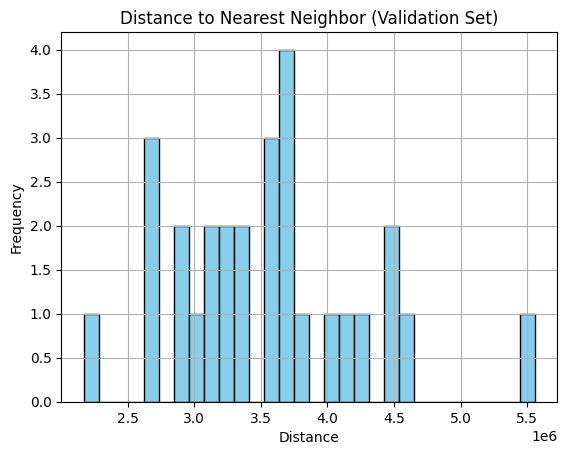

Suggested threshold (95th percentile): 4555144.12


In [31]:
# Use your existing validation data (assumed already scaled via pipeline)
# Replace X_val with your real validation features
distances, _ = knn.kneighbors(X_val, n_neighbors=1)
distances = distances.flatten()

# Plot histogram of distances
plt.hist(distances, bins=30, color='skyblue', edgecolor='black')
plt.title("Distance to Nearest Neighbor (Validation Set)")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Calculate 95th percentile as threshold
threshold = np.percentile(distances, 95)
print(f"Suggested threshold (95th percentile): {threshold:.2f}")
